In [218]:
#type: ignore
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import joblib
df = pd.read_csv("../data/food_delivery_dataset.csv")
print("import is done")

import is done


In [219]:
print(df.shape)
print("\n")
print(df.dtypes)
print("\n")
print(df.info())
print("\n")
df.head()




(45593, 20)


ID                                 str
Delivery_person_ID                 str
Delivery_person_Age                str
Delivery_person_Ratings            str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weatherconditions                  str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries                str
Festival                           str
City                               str
Time_taken(min)                    str
dtype: object


<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19/03/2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25/03/2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19/03/2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05/04/2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26/03/2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


## drop unwanted columns
`ID` and `Delivery_person_ID` have no effect in prediction

In [220]:
df.drop(columns=["ID", "Delivery_person_ID"], inplace=True)
print("columns droped")

columns droped


## cleaning text and convert types

time taken

In [221]:
print(df["Time_taken(min)"].value_counts(dropna=False))

df["Time_taken(min)"] = df["Time_taken(min)"].str.replace("(min)", "",regex=False).str.strip()
df["Time_taken(min)"] = pd.to_numeric(df["Time_taken(min)"], errors='coerce')
print(df.dtypes)

Time_taken(min)
(min) 26    2123
(min) 25    2050
(min) 27    1976
(min) 28    1965
(min) 29    1956
(min) 19    1824
(min) 15    1810
(min) 18    1765
(min) 16    1706
(min) 17    1696
(min) 24    1680
(min) 23    1643
(min) 20    1640
(min) 22    1626
(min) 21    1601
(min) 33    1259
(min) 30    1218
(min) 31    1213
(min) 34    1172
(min) 32    1124
(min) 38     887
(min) 36     852
(min) 39     847
(min) 35     832
(min) 37     828
(min) 11     757
(min) 10     750
(min) 12     746
(min) 14     739
(min) 13     716
(min) 43     567
(min) 42     561
(min) 40     555
(min) 41     553
(min) 44     553
(min) 47     295
(min) 49     280
(min) 48     277
(min) 46     274
(min) 45     241
(min) 53     100
(min) 51      94
(min) 54      91
(min) 52      79
(min) 50      72
Name: count, dtype: int64
Delivery_person_Age                str
Delivery_person_Ratings            str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float6

weather

In [222]:
df["Weatherconditions"] = df["Weatherconditions"].str.replace("conditions ", "",regex=False).str.strip()

clean categorical columns

In [223]:
cat_cols = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "City"
]

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(["NaN", "nan"], np.nan)

person age and person rating 

In [224]:
print(df["Delivery_person_Age"].value_counts(dropna=False))

df["Delivery_person_Age"] = pd.to_numeric(df["Delivery_person_Age"], errors='coerce')
print(df.dtypes)
print(df["Delivery_person_Ratings"].value_counts(dropna=False))

df["Delivery_person_Ratings"] = pd.to_numeric(df["Delivery_person_Ratings"], errors='coerce')
print(df.dtypes)

Delivery_person_Age
35      2262
36      2260
37      2227
30      2226
38      2219
24      2210
32      2202
22      2196
29      2191
33      2187
28      2179
25      2174
34      2166
26      2159
21      2153
27      2150
39      2144
20      2136
31      2120
23      2087
NaN     1854
50        53
15        38
Name: count, dtype: int64
Delivery_person_Age            float64
Delivery_person_Ratings            str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weatherconditions                  str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries                str
Festival                           str
City                           

date

In [225]:
print(df["Order_Date"].value_counts(dropna=False))
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%d/%m/%Y", errors='coerce')
print(df.dtypes)

Order_Date
15/03/2022    1192
03/04/2022    1178
13/03/2022    1169
26/03/2022    1166
24/03/2022    1162
09/03/2022    1159
05/04/2022    1157
05/03/2022    1154
07/03/2022    1153
19/03/2022    1150
03/03/2022    1150
11/03/2022    1149
21/03/2022    1149
30/03/2022    1141
01/03/2022    1140
28/03/2022    1139
17/03/2022    1134
01/04/2022    1133
02/03/2022    1012
10/03/2022     996
16/03/2022     995
20/03/2022     994
02/04/2022     992
06/03/2022     986
04/03/2022     981
29/03/2022     977
25/03/2022     975
14/03/2022     974
11/02/2022     970
18/03/2022     968
31/03/2022     967
27/03/2022     965
12/03/2022     964
08/03/2022     964
23/03/2022     964
06/04/2022     961
13/02/2022     957
15/02/2022     945
04/04/2022     941
17/02/2022     939
12/02/2022     864
16/02/2022     861
18/02/2022     855
14/02/2022     851
Name: count, dtype: int64
Delivery_person_Age                   float64
Delivery_person_Ratings               float64
Restaurant_latitude                

time ordered

In [226]:
print(df["Time_Orderd"].value_counts(dropna=False))
df["Time_Orderd"] = pd.to_timedelta(df["Time_Orderd"], errors='coerce')
print(df.dtypes)

Time_Orderd
NaN         1731
21:55:00     461
17:55:00     456
20:00:00     449
22:20:00     448
            ... 
14:30:00      57
14:15:00      56
16:00:00      53
13:20:00      52
16:30:00      51
Name: count, Length: 177, dtype: int64
Delivery_person_Age                    float64
Delivery_person_Ratings                float64
Restaurant_latitude                    float64
Restaurant_longitude                   float64
Delivery_location_latitude             float64
Delivery_location_longitude            float64
Order_Date                      datetime64[us]
Time_Orderd                    timedelta64[us]
Time_Order_picked                          str
Weatherconditions                          str
Road_traffic_density                       str
Vehicle_condition                        int64
Type_of_order                              str
Type_of_vehicle                            str
multiple_deliveries                        str
Festival                                   str
City      

time order picked

In [227]:
print(df["Time_Order_picked"].value_counts(dropna=False))
df["Time_Order_picked"] = pd.to_timedelta(df["Time_Order_picked"], errors='coerce')
print(df.dtypes)

Time_Order_picked
21:30:00    496
22:50:00    474
22:40:00    458
18:40:00    457
21:45:00    456
           ... 
14:20:00     48
16:15:00     46
16:10:00     43
17:10:00     39
16:20:00     38
Name: count, Length: 193, dtype: int64
Delivery_person_Age                    float64
Delivery_person_Ratings                float64
Restaurant_latitude                    float64
Restaurant_longitude                   float64
Delivery_location_latitude             float64
Delivery_location_longitude            float64
Order_Date                      datetime64[us]
Time_Orderd                    timedelta64[us]
Time_Order_picked              timedelta64[us]
Weatherconditions                          str
Road_traffic_density                       str
Vehicle_condition                        int64
Type_of_order                              str
Type_of_vehicle                            str
multiple_deliveries                        str
Festival                                   str
City           

multi deliveries

In [228]:
print(df["multiple_deliveries"].value_counts(dropna=False))
df["multiple_deliveries"] = pd.to_numeric(df["multiple_deliveries"], errors='coerce')
print(df.dtypes)

multiple_deliveries
1       28159
0       14095
2        1985
NaN       993
3         361
Name: count, dtype: int64
Delivery_person_Age                    float64
Delivery_person_Ratings                float64
Restaurant_latitude                    float64
Restaurant_longitude                   float64
Delivery_location_latitude             float64
Delivery_location_longitude            float64
Order_Date                      datetime64[us]
Time_Orderd                    timedelta64[us]
Time_Order_picked              timedelta64[us]
Weatherconditions                          str
Road_traffic_density                       str
Vehicle_condition                        int64
Type_of_order                              str
Type_of_vehicle                            str
multiple_deliveries                    float64
Festival                                   str
City                                       str
Time_taken(min)                          int64
dtype: object


In [229]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,0 days 11:30:00,0 days 11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,0 days 19:45:00,0 days 19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,0 days 08:30:00,0 days 08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,0 days 18:00:00,0 days 18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,0 days 13:30:00,0 days 13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30


## detection of mssing values

correct invalid coordinate using absolut and removing values under 1

In [230]:
coord_cols = [
    "Restaurant_latitude", 
    "Restaurant_longitude", 
    "Delivery_location_latitude", 
    "Delivery_location_longitude"
]
df[coord_cols]=df[coord_cols].abs()
invalid_coords_mask = (df[coord_cols] < 1.0).any(axis=1)
df = df[~invalid_coords_mask]
print("New dataset shape:", df.shape)

New dataset shape: (41953, 18)


## checking for missing values 

In [231]:
df.isna().sum()

Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions               569
Road_traffic_density            555
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                          0
City                           1114
Time_taken(min)                   0
dtype: int64

## handling missing values

person age

In [232]:
df["Delivery_person_Age"].describe()

count    40234.000000
mean        29.563330
std          5.812361
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

In [233]:
df["Delivery_person_Age"]=df["Delivery_person_Age"].fillna(df["Delivery_person_Age"].median())

waether conditions

In [234]:
df["Weatherconditions"] = df["Weatherconditions"].fillna(
    df["Weatherconditions"].mode()[0]
)

cities

In [235]:
df["City"] = df["City"].fillna(df["City"].mode()[0])

traffic density

In [236]:
df["Road_traffic_density"]= df["Road_traffic_density"].fillna(df["Road_traffic_density"].mode()[0])

time ordered

In [237]:
df = df.dropna(subset=["Time_Orderd"])

multi deliveries

In [238]:
df["multiple_deliveries"].describe()

count    39498.00000
mean         0.74462
std          0.57227
min          0.00000
25%          0.00000
50%          1.00000
75%          1.00000
max          3.00000
Name: multiple_deliveries, dtype: float64

In [239]:
df["multiple_deliveries"] = df["multiple_deliveries"].fillna(df["multiple_deliveries"].median())

drop duplicated

In [240]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("New dataset shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0


In [241]:
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(df["Delivery_person_Ratings"].median())

checking

In [242]:
print(df.shape)
print()
print(df.isna().sum())

(40353, 18)

Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64


# EDA

In [243]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Delivery_person_Age,40353.0,29.554829,20.0,25.0,30.0,35.0,39.0,5.746713
Delivery_person_Ratings,40353.0,4.634387,2.5,4.5,4.7,4.9,5.0,0.313975
Restaurant_latitude,40353.0,18.911836,9.957144,12.986047,19.065838,22.751234,30.914057,5.468296
Restaurant_longitude,40353.0,76.91848,72.768726,73.897902,76.618203,78.368855,88.433452,3.500531
Delivery_location_latitude,40353.0,18.975471,9.967144,13.065996,19.124049,22.82004,31.054057,5.470105
Delivery_location_longitude,40353.0,76.982116,72.778726,73.940327,76.662278,78.403391,88.563452,3.500743
Order_Date,40353,2022-03-14 04:52:45.623373,2022-02-11 00:00:00,2022-03-05 00:00:00,2022-03-15 00:00:00,2022-03-27 00:00:00,2022-04-06 00:00:00,NaN
Time_Orderd,40353,0 days 17:54:52.431789,0 days 00:00:00,0 days 15:25:00,0 days 19:15:00,0 days 21:35:00,0 days 23:55:00,0 days 04:50:17.422557
Time_Order_picked,40353,0 days 17:37:39.631254,0 days 00:00:00,0 days 14:35:00,0 days 19:10:00,0 days 21:35:00,0 days 23:55:00,0 days 05:21:15.788260
Vehicle_condition,40353.0,0.999876,0.0,0.0,1.0,2.0,2.0,0.816218


### distribution of time taken

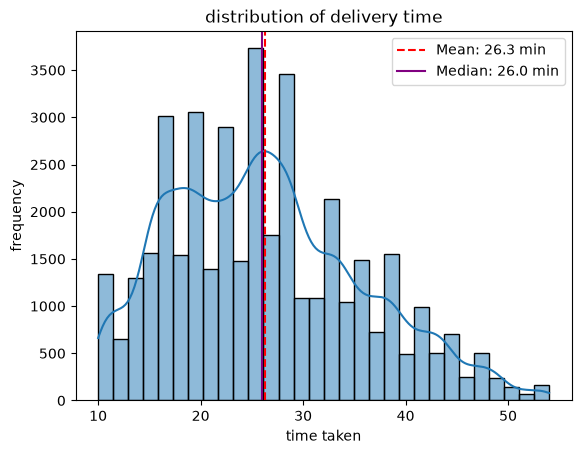

In [244]:
sns.histplot(df["Time_taken(min)"], kde=True, bins=30)

plt.axvline(
    df["Time_taken(min)"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {df['Time_taken(min)'].mean():.1f} min",
)
plt.axvline(
    df["Time_taken(min)"].median(),
    color="purple",
    linestyle="-",
    label=f"Median: {df['Time_taken(min)'].median():.1f} min",
)

plt.title("distribution of delivery time")
plt.xlabel("time taken")
plt.ylabel("frequency")
plt.legend()
plt.show()

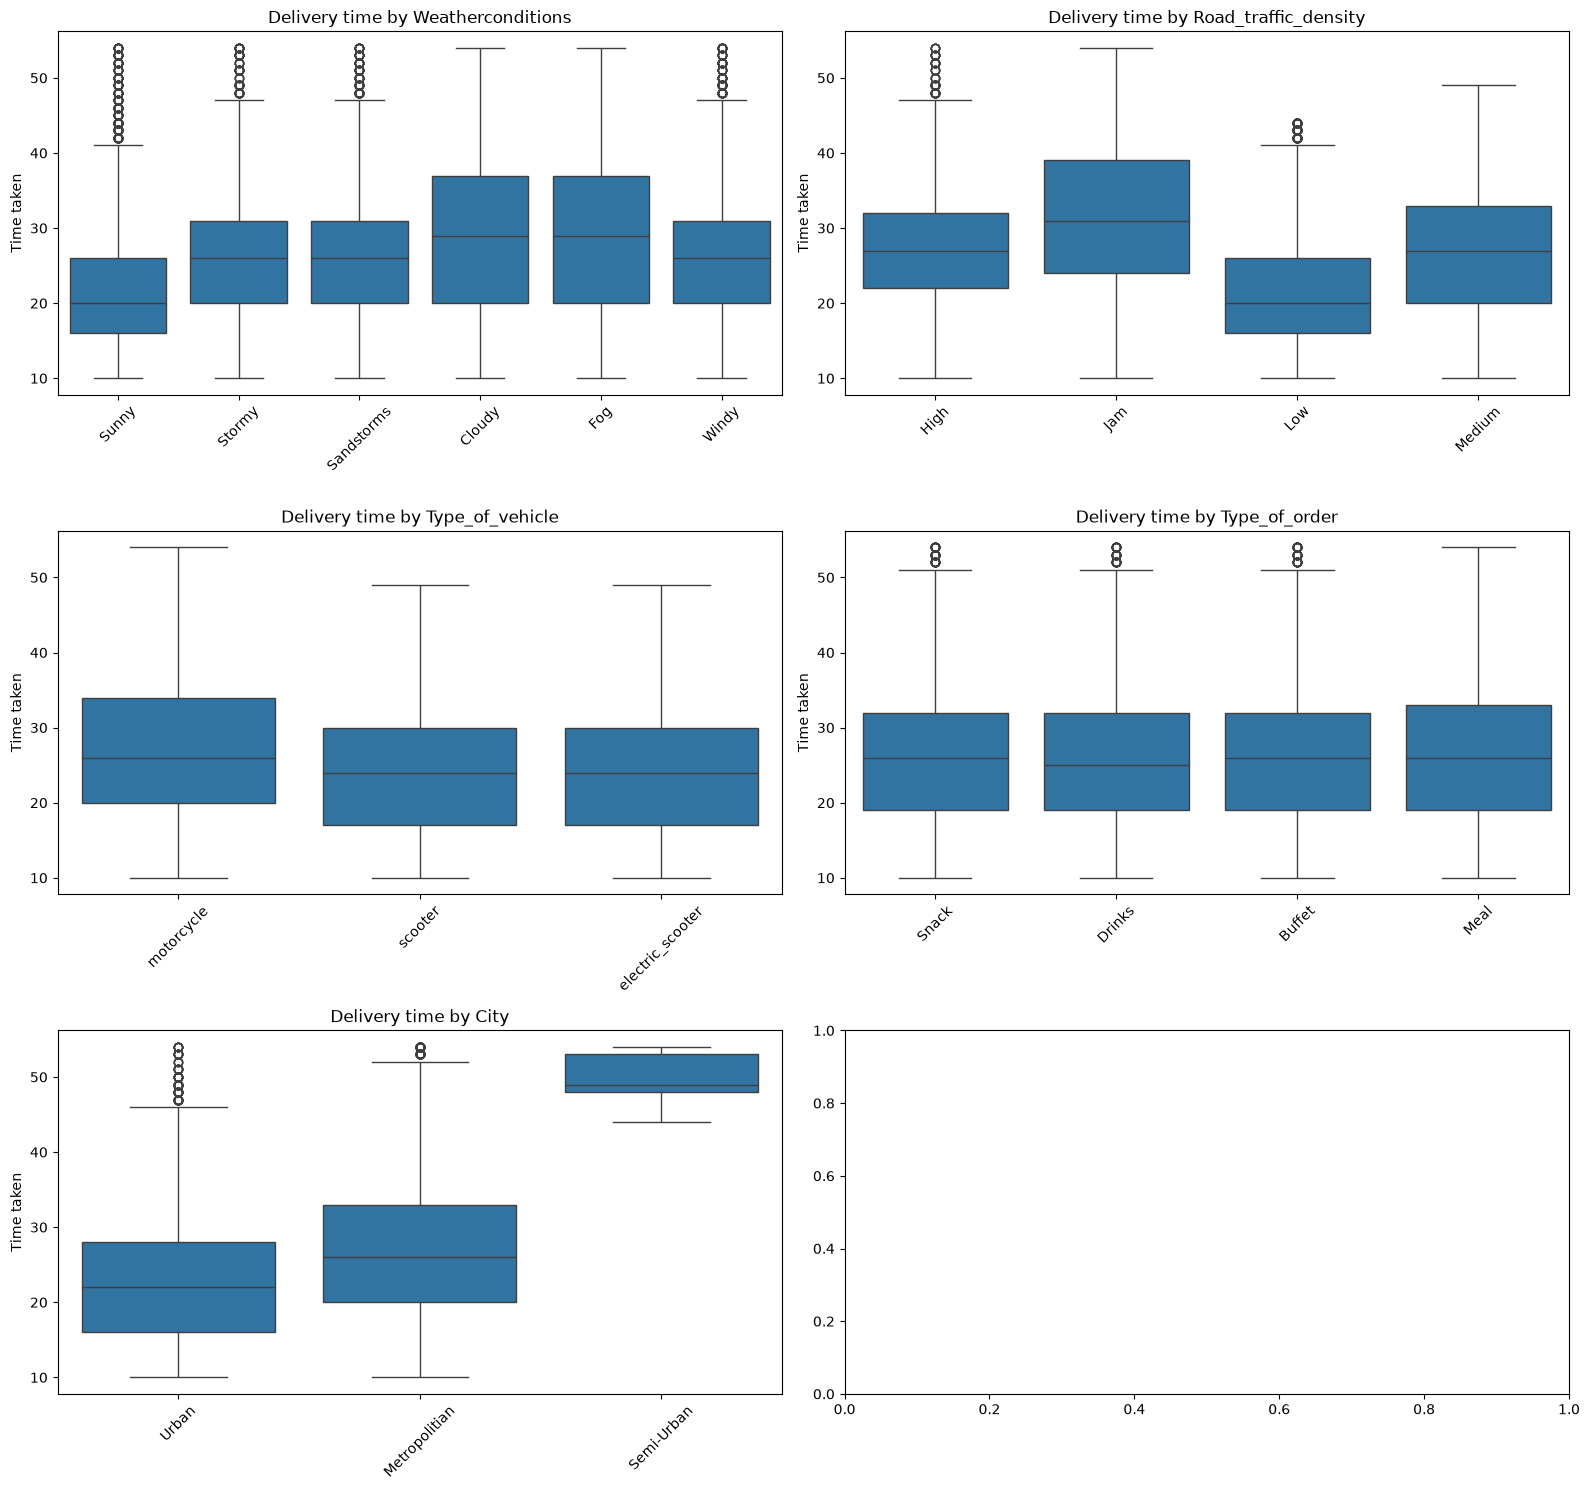

In [245]:
categorical_to_plot = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_vehicle",
    "Type_of_order",
    "City",
]

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

for idx, col in enumerate(categorical_to_plot):
    sns.boxplot(
        data=df,
        x=col,
        y="Time_taken(min)",
        ax=axes[idx]
    )
    axes[idx].set_title(f"Delivery time by {col}")
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("Time taken")
    axes[idx].tick_params(axis="x", rotation=45)


plt.tight_layout()
plt.show()

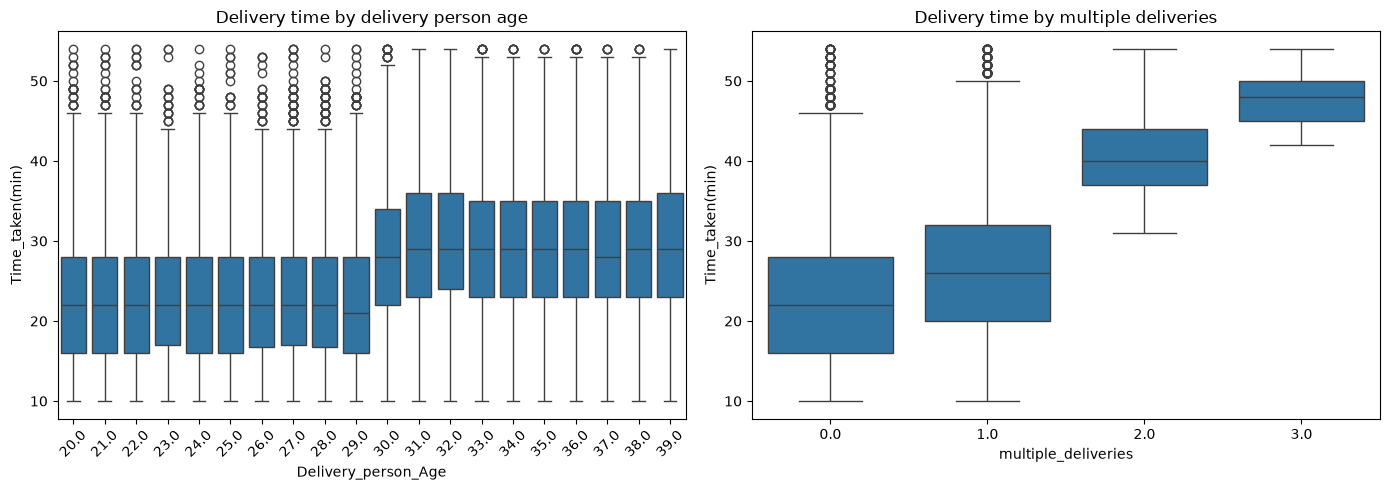

In [246]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x="Delivery_person_Age",
    y="Time_taken(min)",
    ax=axes[0],
)
axes[0].set_title("Delivery time by delivery person age")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=df,
    x="multiple_deliveries",
    y="Time_taken(min)",
    ax=axes[1],
)
axes[1].set_title("Delivery time by multiple deliveries")

plt.tight_layout()
plt.show()

In [247]:
R= 6371
lat1=np.radians(df["Delivery_location_latitude"])
lng1=np.radians(df["Delivery_location_longitude"])
lat2=np.radians(df["Restaurant_latitude"])
lng2=np.radians(df["Restaurant_longitude"])
dlat=lat2-lat1
dlng=lng2-lng1
a = np.sin(dlat/2)**2+np.cos(lat1)*np.cos(lat2)*np.sin(dlng/2)**2
df["distance_km"]=2 * R * np.arcsin(np.sqrt(a))

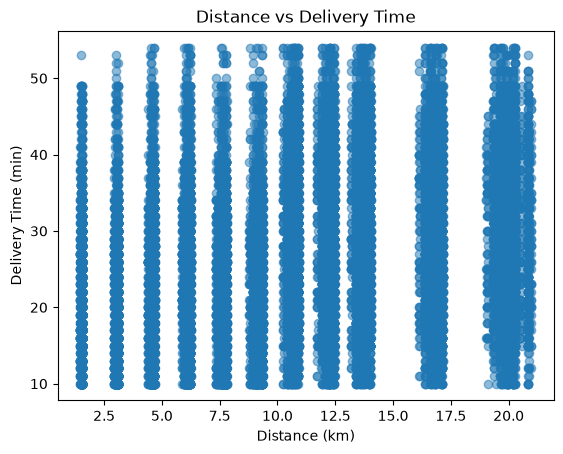

In [248]:

plt.scatter(
    df["distance_km"],
    df["Time_taken(min)"],
    alpha=0.5
)

plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.title("Distance vs Delivery Time")

plt.show()

In [249]:
# df["speed_kmh"] = df["distance_km"] / (df["Time_taken(min)"] / 60)
# df = df[(df["speed_kmh"] >= 1) & (df["speed_kmh"] <= 100)]
# df["speed_kmh"].describe()
# sns.histplot(df["speed_kmh"], bins=50)

In [250]:
df["prep_time_min"] = (
    df["Time_Order_picked"] - df["Time_Orderd"]
).dt.total_seconds() / 60.0

df["prep_time_min"] = df["prep_time_min"].apply(
    lambda x: x + 1440 if x < 0 else x
)

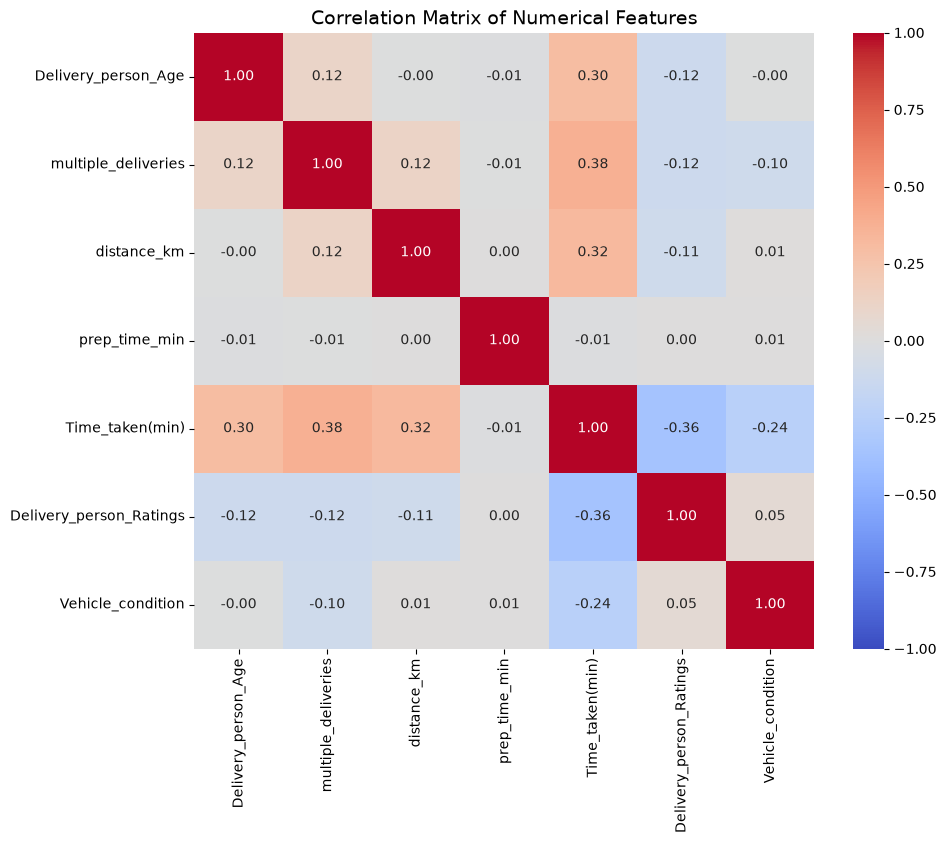

In [251]:
numeric_subset = df[
    [
        "Delivery_person_Age",
        "multiple_deliveries",
        "distance_km",
        "prep_time_min",
        "Time_taken(min)",
        "Delivery_person_Ratings",
        "Vehicle_condition"
    ]
]

plt.figure(figsize=(10, 8))
correlation_matrix = numeric_subset.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
plt.title("Correlation Matrix of Numerical Features", fontsize=14)
plt.show()


In [252]:
df=df.drop(columns=["Delivery_location_latitude", "Delivery_location_longitude","Restaurant_latitude","Restaurant_longitude","Time_Order_picked","Time_Orderd"])

In [253]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Order_Date,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),distance_km,prep_time_min
0,37.0,4.9,2022-03-19,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24,3.025149,15.0
1,34.0,4.5,2022-03-25,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,20.183530,5.0
2,23.0,4.4,2022-03-19,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26,1.552758,15.0
3,38.0,4.7,2022-04-05,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,7.790401,10.0
4,32.0,4.6,2022-03-26,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30,6.210138,15.0



# Numerical: mean because the distribution has no significant outliers

In [254]:
for column in ["Delivery_person_Age", "prep_time_min", "Time_taken(min)"]:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(column, ":", len(outliers), "outliers")


Delivery_person_Age : 0 outliers
prep_time_min : 0 outliers
Time_taken(min) : 232 outliers


In [255]:

num_features = [
    "Delivery_person_Age",
    "multiple_deliveries",
    "distance_km",
    "prep_time_min",
    "Delivery_person_Ratings",
    "Vehicle_condition",
]

ordinal_features = ["Road_traffic_density"]


traffic_order = [["Low", "Medium", "High", "Jam"]]

nominal_features = [
    "Weatherconditions",
    "Type_of_vehicle",
    "City",
    "Festival",
]

all_features = (
    num_features
    + ordinal_features
    + [col for col in nominal_features if col in df.columns]
)

X = df[all_features]
y = df["Time_taken(min)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# define the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        (
            "ord",
            OrdinalEncoder(
                categories=traffic_order,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            ordinal_features,
        ),
        (
            "nom",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            [col for col in nominal_features if col in df.columns],
        ),
    ]
)

In [256]:
# test the 8 candidate models

models = {
    # "Linear Regression": LinearRegression(),
    # "Ridge": Ridge(),
    # "Random Forest": RandomForestRegressor(),
    # "Gradient Boosting": GradientBoostingRegressor(),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(),
    # "Decision Tree": DecisionTreeRegressor(random_state=42),
    # "Extra Trees": ExtraTreesRegressor(random_state=42, n_jobs=-1),
    # "SVR": SVR()
}

results = []

for name, model in models.items():
    print(f"Training {name}...")

    pipe = Pipeline(
        steps=[("preprocessor", preprocessor), ("regressor", model)]
    )

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)


    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE (min)": mae, "RMSE (min)": rmse, "R²": r2})

# benchmark results
results_df = pd.DataFrame(results)
print("\n--- MODEL BENCHMARK RESULTS ---")
print(results_df)

Training Hist Gradient Boosting...

--- MODEL BENCHMARK RESULTS ---
                    Model  MAE (min)  RMSE (min)      R²
0  Hist Gradient Boosting   3.045394    3.780015  0.8376


tuning hgb best model

In [257]:

hist_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            HistGradientBoostingRegressor(
                random_state=42
            )
        ),
    ]
)


param_distributions = {
    "regressor__max_iter": [100,150,200,300],

    "regressor__learning_rate": [0.01,0.03,0.05,0.1],

    "regressor__max_leaf_nodes": [15,20,30,40,50],

    "regressor__min_samples_leaf": [10,20,30,50],

    "regressor__l2_regularization": [0,0.1,1,5,10]
}

random_search = RandomizedSearchCV(
    estimator=hist_pipeline,
    param_distributions=param_distributions,
    n_iter=150,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting Hist Gradient Boosting hyperparameter tuning...")

random_search.fit(X_train, y_train)

print("Hyperparameter tuning finished!")


print("\n--- BEST PARAMETERS ---")

print(random_search.best_params_)

print("\nBest Cross-Validation MAE:")
print(f"{-random_search.best_score_:.3f} minutes")



best_hist_pipeline = random_search.best_estimator_


train_preds = best_hist_pipeline.predict(X_train)

train_mae = mean_absolute_error(
    y_train,
    train_preds
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_preds
    )
)

train_r2 = r2_score(
    y_train,
    train_preds
)


test_preds = best_hist_pipeline.predict(X_test)

test_mae = mean_absolute_error(
    y_test,
    test_preds
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_preds
    )
)

test_r2 = r2_score(
    y_test,
    test_preds
)


print("\n--- FINAL HIST GRADIENT BOOSTING EVALUATION ---")

print(f"Train MAE:  {train_mae:.3f} min")
print(f"Train RMSE: {train_rmse:.3f} min")
print(f"Train R²:   {train_r2:.3f}")

print()

print(f"Test MAE:   {test_mae:.3f} min")
print(f"Test RMSE:  {test_rmse:.3f} min")
print(f"Test R²:    {test_r2:.3f}")



mae_gap = test_mae - train_mae
r2_gap = train_r2 - test_r2

print("\n--- GENERALIZATION GAP ---")

print(f"MAE gap: {mae_gap:.3f} min")
print(f"R² gap:  {r2_gap:.3f}")



n = X_test.shape[0]
p = X_test.shape[1]

test_adjusted_r2 = 1 - (
    (1 - test_r2) * (n - 1) / (n - p - 1)
)

print(f"Test Adjusted R²: {test_adjusted_r2:.3f}")


joblib.dump(
    best_hist_pipeline,
    "../model/best_delivery_pipeline.joblib"
)
print(
    "\nBest Hist Gradient Boosting pipeline saved successfully!"
)

Starting Hist Gradient Boosting hyperparameter tuning...
Fitting 3 folds for each of 150 candidates, totalling 450 fits
Hyperparameter tuning finished!

--- BEST PARAMETERS ---
{'regressor__min_samples_leaf': 20, 'regressor__max_leaf_nodes': 50, 'regressor__max_iter': 200, 'regressor__learning_rate': 0.05, 'regressor__l2_regularization': 5}

Best Cross-Validation MAE:
3.048 minutes

--- FINAL HIST GRADIENT BOOSTING EVALUATION ---
Train MAE:  2.891 min
Train RMSE: 3.580 min
Train R²:   0.854

Test MAE:   3.002 min
Test RMSE:  3.717 min
Test R²:    0.843

--- GENERALIZATION GAP ---
MAE gap: 0.111 min
R² gap:  0.011
Test Adjusted R²: 0.843

Best Hist Gradient Boosting pipeline saved successfully!


In [258]:
df.to_csv("../data/df_clean.csv", index=False)